🎲 Resultado de Simulación Monte Carlo (10000 usuarios):
E: 0.270
Ne: 0.040
N: 0.298
Ni: 0.214
I: 0.178


C:\Users\leshi\AppData\Local\Temp\ipykernel_31820\1950485128.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo.index, y=conteo.values, palette="viridis")
C:\Users\leshi\AppData\Local\Temp\ipykernel_31820\1950485128.py:50: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from current font.
  plt.tight_layout()
C:\Users\leshi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


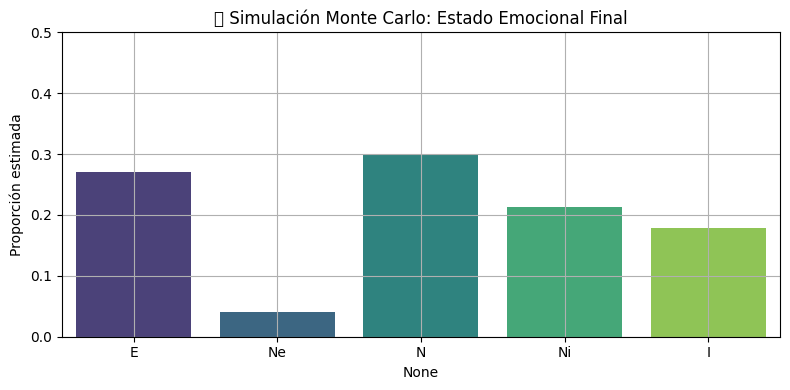

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Matriz de transición (misma que usaste)
trans_probs = np.array([
    [0.541, 0.037, 0.129, 0.290, 0.003],  # E
    [0.066, 0.058, 0.219, 0.569, 0.088],  # Ne
    [0.065, 0.010, 0.389, 0.166, 0.370],  # N
    [0.407, 0.065, 0.121, 0.263, 0.144],  # Ni
    [0.077, 0.050, 0.632, 0.066, 0.175],  # I
])


# Estados
estados = ["E", "Ne", "N", "Ni", "I"]
estado_map = {i: estado for i, estado in enumerate(estados)}

# Distribución inicial (uniforme o definida por ti)
dist_inicial = [0.0, 0.0, 0.96, 0.03, 0.01]  # O usa tus datos reales

# Función de simulación
def simular_usuario(pasos=12):
    estado = np.random.choice(5, p=dist_inicial)
    for _ in range(pasos - 1):
        estado = np.random.choice(5, p=trans_probs[estado])
    return estado

# Ejecutar simulación de Monte Carlo
n_simulaciones = 10000
finales = [simular_usuario() for _ in range(n_simulaciones)]

# Calcular proporciones
conteo = pd.Series(finales).value_counts(normalize=True).sort_index()
conteo.index = [estado_map[i] for i in conteo.index]

# Mostrar resultados
print("🎲 Resultado de Simulación Monte Carlo (10000 usuarios):")
for estado, prob in conteo.items():
    print(f"{estado}: {prob:.3f}")

# Visualizar
plt.figure(figsize=(8, 4))
sns.barplot(x=conteo.index, y=conteo.values, palette="viridis")
plt.title("🔮 Simulación Monte Carlo: Estado Emocional Final")
plt.ylabel("Proporción estimada")
plt.ylim(0, 0.5)
plt.grid(True)
plt.tight_layout()
plt.show()
